GPU-optimized synthetic banking network model for NVIDIA A100 / CUDA PyTorch
with two stress scenarios:

1) Targeted_Core  -> shock largest core bank
2) Random         -> shock random bank

Outputs saved
-------------
- advanced_distortion_runs.csv
- advanced_contagion_runs.csv
- advanced_distortion_summary.csv
- advanced_contagion_summary.csv
- paper_overall_summary_by_scenario.csv
- paper_structural_table_by_scenario.csv
- paper_contagion_table_by_scenario.csv
- paper_robustness_table_by_scenario.csv

Also prints key paper tables in notebook / Collab.

In [ ]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import math
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


# =========================================================
# Global device config
# =========================================================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DTYPE = torch.float32
LTYPE = torch.long

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# Utilities

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str | Path) -> Path:
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p


def to_cpu_numpy(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()

# Pareto sampling on GPU

def sample_truncated_pareto_vector_gpu(
    n: int,
    alpha: float,
    xmin: int = 1,
    xmax: Optional[int] = None,
    target_mean: Optional[float] = None,
    tolerance: float = 0.5,
    max_attempts: int = 1000,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    if xmax is None:
        xmax = max(5, int(0.35 * n))
    xmax = min(xmax, n - 1)

    if xmax < 1:
        raise ValueError("xmax must be at least 1.")
    if target_mean is not None and target_mean > xmax:
        raise ValueError("target_mean cannot exceed xmax.")

    for _ in range(max_attempts):
        u = torch.rand(n, device=device, dtype=DTYPE).clamp_(1e-7, 1 - 1e-7)
        x = xmin * torch.pow(1.0 - u, -1.0 / alpha)
        x = torch.floor(x).to(LTYPE)
        x = torch.clamp(x, 0, xmax)

        if int(x.sum().item()) == 0:
            idx = torch.randint(0, n, (1,), device=device)
            x[idx] = 1

        if target_mean is not None:
            current_mean = x.float().mean()
            if current_mean <= 0:
                continue

            scale = target_mean / float(current_mean.item())
            x = torch.round(x.float() * scale).to(LTYPE)
            x = torch.clamp(x, 0, xmax)

            target_sum = int(round(target_mean * n))
            diff = target_sum - int(x.sum().item())

            safety = 0
            while diff != 0 and safety < 20 * n:
                if diff > 0:
                    cand = torch.where(x < xmax)[0]
                    if cand.numel() == 0:
                        break
                    idx = cand[torch.randint(0, cand.numel(), (1,), device=device)]
                    x[idx] += 1
                    diff -= 1
                else:
                    cand = torch.where(x > 0)[0]
                    if cand.numel() == 0:
                        break
                    idx = cand[torch.randint(0, cand.numel(), (1,), device=device)]
                    x[idx] -= 1
                    diff += 1
                safety += 1

        if target_mean is None or abs(float(x.float().mean().item()) - target_mean) <= tolerance:
            return x

    raise RuntimeError("Could not sample a Pareto vector with requested constraints.")


def balance_directed_degree_sequences_gpu(
    out_deg: torch.Tensor,
    in_deg: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    out_deg = out_deg.clone()
    in_deg = in_deg.clone()

    diff = int(out_deg.sum().item() - in_deg.sum().item())

    if diff > 0:
        idx = torch.randint(0, len(in_deg), (diff,), device=in_deg.device)
        in_deg.index_add_(0, idx, torch.ones(diff, device=in_deg.device, dtype=LTYPE))
    elif diff < 0:
        idx = torch.randint(0, len(out_deg), (-diff,), device=out_deg.device)
        out_deg.index_add_(0, idx, torch.ones(-diff, device=out_deg.device, dtype=LTYPE))

    return out_deg, in_deg

# Bank system and balance sheets

def sample_bank_sizes_gpu(
    n: int,
    alpha: float = 1.4,
    min_assets: float = 1e3,
    total_assets: float = 1e8,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    u = torch.rand(n, device=device, dtype=DTYPE).clamp_(1e-7, 1 - 1e-7)
    assets = min_assets * torch.pow(1.0 - u, -1.0 / alpha)
    assets = assets / assets.sum() * total_assets
    return assets


def assign_core_periphery_gpu(
    n: int,
    core_fraction: float = 0.15,
    by_size_rank: Optional[torch.Tensor] = None,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    k = max(1, int(round(core_fraction * n)))
    core = torch.zeros(n, device=device, dtype=LTYPE)

    if by_size_rank is None:
        idx = torch.randperm(n, device=device)[:k]
    else:
        idx = torch.argsort(by_size_rank, descending=True)[:k]

    core[idx] = 1
    return core


def build_balance_sheet_tensors_gpu(
    assets: torch.Tensor,
    core_flag: torch.Tensor,
    equity_ratio_core: float = 0.07,
    equity_ratio_periphery: float = 0.09,
    liquid_asset_share_core: float = 0.18,
    liquid_asset_share_periphery: float = 0.24,
    interbank_asset_share_core: float = 0.20,
    interbank_asset_share_periphery: float = 0.08,
    runnable_funding_share_core: float = 0.22,
    runnable_funding_share_periphery: float = 0.12,
) -> Dict[str, torch.Tensor]:
    core_mask = core_flag == 1

    equity_ratio = torch.where(
        core_mask,
        torch.tensor(equity_ratio_core, device=assets.device, dtype=DTYPE),
        torch.tensor(equity_ratio_periphery, device=assets.device, dtype=DTYPE),
    )
    liquid_share = torch.where(
        core_mask,
        torch.tensor(liquid_asset_share_core, device=assets.device, dtype=DTYPE),
        torch.tensor(liquid_asset_share_periphery, device=assets.device, dtype=DTYPE),
    )
    interbank_asset_share = torch.where(
        core_mask,
        torch.tensor(interbank_asset_share_core, device=assets.device, dtype=DTYPE),
        torch.tensor(interbank_asset_share_periphery, device=assets.device, dtype=DTYPE),
    )
    runnable_funding_share = torch.where(
        core_mask,
        torch.tensor(runnable_funding_share_core, device=assets.device, dtype=DTYPE),
        torch.tensor(runnable_funding_share_periphery, device=assets.device, dtype=DTYPE),
    )

    equity = assets * equity_ratio
    liabilities = assets - equity
    liquid_assets = assets * liquid_share
    interbank_assets_target = assets * interbank_asset_share
    illiquid_assets = assets - liquid_assets
    runnable_funding = liabilities * runnable_funding_share

    return {
        "node": torch.arange(len(assets), device=assets.device, dtype=LTYPE),
        "assets": assets,
        "equity": equity,
        "liabilities": liabilities,
        "liquid_assets": liquid_assets,
        "illiquid_assets": illiquid_assets,
        "interbank_assets_target": interbank_assets_target,
        "runnable_funding": runnable_funding,
        "core": core_flag,
    }

# Edge sampling helpers

def unique_edges_gpu(edges: torch.Tensor) -> torch.Tensor:
    if edges.numel() == 0:
        return edges.reshape(0, 2)
    return torch.unique(edges, dim=0)


def sample_unique_edges_from_probs_gpu(
    source_probs: torch.Tensor,
    target_probs: torch.Tensor,
    m: int,
    allow_self: bool = False,
    oversample: float = 1.35,
    max_rounds: int = 10,
) -> torch.Tensor:
    device = source_probs.device
    edges = torch.empty((0, 2), device=device, dtype=LTYPE)

    needed = m
    for _ in range(max_rounds):
        k = int(max(math.ceil(needed * oversample), needed + 1024))
        src = torch.multinomial(source_probs, k, replacement=True)
        tgt = torch.multinomial(target_probs, k, replacement=True)
        pairs = torch.stack([src, tgt], dim=1)

        if not allow_self:
            pairs = pairs[pairs[:, 0] != pairs[:, 1]]

        if edges.numel() > 0:
            pairs = torch.cat([edges, pairs], dim=0)

        pairs = unique_edges_gpu(pairs)

        if pairs.shape[0] >= m:
            return pairs[:m]

        edges = pairs
        needed = m - edges.shape[0]

    return edges[:m]


# Directed graph generators

def directed_stub_matching_ecm_gpu(
    out_deg: torch.Tensor,
    in_deg: torch.Tensor,
) -> torch.Tensor:
    n = out_deg.numel()
    device = out_deg.device

    out_stubs = torch.repeat_interleave(torch.arange(n, device=device, dtype=LTYPE), out_deg)
    in_stubs = torch.repeat_interleave(torch.arange(n, device=device, dtype=LTYPE), in_deg)

    m = min(out_stubs.numel(), in_stubs.numel())
    if m == 0:
        return torch.empty((0, 2), device=device, dtype=LTYPE)

    perm_out = torch.randperm(out_stubs.numel(), device=device)[:m]
    perm_in = torch.randperm(in_stubs.numel(), device=device)[:m]

    src = out_stubs[perm_out]
    tgt = in_stubs[perm_in]

    edges = torch.stack([src, tgt], dim=1)
    edges = edges[edges[:, 0] != edges[:, 1]]
    edges = unique_edges_gpu(edges)
    return edges


def directed_chung_lu_graph_gpu(
    out_deg_target: torch.Tensor,
    in_deg_target: torch.Tensor,
) -> torch.Tensor:
    m = int(out_deg_target.sum().item())
    if m <= 0:
        return torch.empty((0, 2), device=out_deg_target.device, dtype=LTYPE)

    source_probs = out_deg_target.float()
    target_probs = in_deg_target.float()

    source_probs = source_probs / source_probs.sum()
    target_probs = target_probs / target_probs.sum()

    return sample_unique_edges_from_probs_gpu(source_probs, target_probs, m, allow_self=False)


def fitness_gravity_directed_graph_gpu(
    out_deg_target: torch.Tensor,
    in_deg_target: torch.Tensor,
    assets: torch.Tensor,
    core_flag: torch.Tensor,
    size_mix: float = 0.55,
    degree_mix: float = 0.45,
    core_boost: float = 1.10,
) -> torch.Tensor:
    m = int(out_deg_target.sum().item())
    if m <= 0:
        return torch.empty((0, 2), device=out_deg_target.device, dtype=LTYPE)

    out_strength = out_deg_target.float() / max(float(out_deg_target.sum().item()), 1.0)
    in_strength = in_deg_target.float() / max(float(in_deg_target.sum().item()), 1.0)
    asset_share = assets / assets.sum()

    source_score = degree_mix * out_strength + size_mix * asset_share
    target_score = degree_mix * in_strength + size_mix * asset_share

    core_mult = 1.0 + (core_boost - 1.0) * core_flag.float()
    source_score = source_score * core_mult
    target_score = target_score * core_mult

    source_score = source_score / source_score.sum()
    target_score = target_score / target_score.sum()

    return sample_unique_edges_from_probs_gpu(source_score, target_score, m, allow_self=False)


# Metrics

def hill_tail_exponent_np(x: np.ndarray, xmin: int = 2) -> float:
    x = np.asarray(x, dtype=float)
    x = x[x >= xmin]
    if len(x) < 5:
        return np.nan
    denom = np.sum(np.log(x / xmin))
    if denom <= 0:
        return np.nan
    return 1.0 + len(x) / denom


def top_k_share_np(x: np.ndarray, frac: float = 0.05) -> float:
    x = np.sort(np.asarray(x))[::-1]
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    k = max(1, int(math.ceil(frac * len(x))))
    return float(x[:k].sum() / x.sum())


def safe_gini_np(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    if np.allclose(x.sum(), 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n)


def hhi_np(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    s = x.sum()
    if s <= 0:
        return 0.0
    p = x / s
    return float(np.sum(p ** 2))


def percentile_np(x: np.ndarray, q: float) -> float:
    if len(x) == 0:
        return np.nan
    return float(np.percentile(x, q))


def top_share_np(x: np.ndarray, frac: float) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or x.sum() <= 0:
        return np.nan
    k = max(1, int(math.ceil(frac * len(x))))
    x = np.sort(x)[::-1]
    return float(x[:k].sum() / x.sum())


def directed_degree_summary_from_edges(
    n: int,
    edges: torch.Tensor,
) -> Dict[str, float]:
    if edges.numel() == 0:
        out_deg = np.zeros(n, dtype=int)
        in_deg = np.zeros(n, dtype=int)
        n_edges = 0
    else:
        src = edges[:, 0]
        tgt = edges[:, 1]
        out_deg = to_cpu_numpy(torch.bincount(src, minlength=n))
        in_deg = to_cpu_numpy(torch.bincount(tgt, minlength=n))
        n_edges = int(edges.shape[0])

    density = n_edges / max(n * (n - 1), 1)

    return {
        "avg_out_degree": float(out_deg.mean()),
        "avg_in_degree": float(in_deg.mean()),
        "max_out_degree": int(out_deg.max()) if len(out_deg) else 0,
        "max_in_degree": int(in_deg.max()) if len(in_deg) else 0,
        "out_top_5pct_share": top_k_share_np(out_deg, 0.05),
        "in_top_5pct_share": top_k_share_np(in_deg, 0.05),
        "out_tail_alpha_hat": hill_tail_exponent_np(out_deg, xmin=2),
        "in_tail_alpha_hat": hill_tail_exponent_np(in_deg, xmin=2),
        "n_edges": n_edges,
        "density": density,
    }


def extended_degree_metrics_from_edges(
    n: int,
    edges: torch.Tensor,
) -> Dict[str, float]:
    if edges.numel() == 0:
        out_deg = np.zeros(n, dtype=int)
        in_deg = np.zeros(n, dtype=int)
    else:
        src = edges[:, 0]
        tgt = edges[:, 1]
        out_deg = to_cpu_numpy(torch.bincount(src, minlength=n))
        in_deg = to_cpu_numpy(torch.bincount(tgt, minlength=n))

    return {
        "out_p95": percentile_np(out_deg, 95),
        "out_p99": percentile_np(out_deg, 99),
        "in_p95": percentile_np(in_deg, 95),
        "in_p99": percentile_np(in_deg, 99),
        "out_top_1pct_share": top_share_np(out_deg, 0.01),
        "in_top_1pct_share": top_share_np(in_deg, 0.01),
        "out_degree_gini": safe_gini_np(out_deg),
        "in_degree_gini": safe_gini_np(in_deg),
        "zero_out_degree_share": float((out_deg == 0).mean()),
        "zero_in_degree_share": float((in_deg == 0).mean()),
    }


def realized_edge_type_shares(
    edges: torch.Tensor,
    core_flag: torch.Tensor,
) -> Dict[str, float]:
    if edges.numel() == 0:
        return {
            "share_cc_edges": 0.0,
            "share_cp_edges": 0.0,
            "share_pc_edges": 0.0,
            "share_pp_edges": 0.0,
        }

    src = edges[:, 0]
    tgt = edges[:, 1]
    src_core = core_flag[src]
    tgt_core = core_flag[tgt]

    cc = ((src_core == 1) & (tgt_core == 1)).sum().item()
    cp = ((src_core == 1) & (tgt_core == 0)).sum().item()
    pc = ((src_core == 0) & (tgt_core == 1)).sum().item()
    pp = ((src_core == 0) & (tgt_core == 0)).sum().item()

    total = max(edges.shape[0], 1)

    return {
        "share_cc_edges": cc / total,
        "share_cp_edges": cp / total,
        "share_pc_edges": pc / total,
        "share_pp_edges": pp / total,
    }


def realized_exposure_type_shares(
    edges: torch.Tensor,
    edge_exposure: torch.Tensor,
    core_flag: torch.Tensor,
) -> Dict[str, float]:
    if edges.numel() == 0 or edge_exposure.numel() == 0:
        return {
            "share_cc_exposure": 0.0,
            "share_cp_exposure": 0.0,
            "share_pc_exposure": 0.0,
            "share_pp_exposure": 0.0,
        }

    src = edges[:, 0]
    tgt = edges[:, 1]
    src_core = core_flag[src]
    tgt_core = core_flag[tgt]

    total = float(edge_exposure.sum().item())
    if total <= 0:
        total = 1.0

    cc = edge_exposure[(src_core == 1) & (tgt_core == 1)].sum().item()
    cp = edge_exposure[(src_core == 1) & (tgt_core == 0)].sum().item()
    pc = edge_exposure[(src_core == 0) & (tgt_core == 1)].sum().item()
    pp = edge_exposure[(src_core == 0) & (tgt_core == 0)].sum().item()

    return {
        "share_cc_exposure": cc / total,
        "share_cp_exposure": cp / total,
        "share_pc_exposure": pc / total,
        "share_pp_exposure": pp / total,
    }


def exposure_concentration_metrics(
    edges: torch.Tensor,
    edge_exposure: torch.Tensor,
    n: int,
) -> Dict[str, float]:
    if edges.numel() == 0 or edge_exposure.numel() == 0:
        return {
            "exposure_hhi_total": 0.0,
            "out_exposure_hhi": 0.0,
            "in_exposure_hhi": 0.0,
            "top_5pct_exposure_share": 0.0,
            "top_1pct_exposure_share": 0.0,
            "largest_edge_exposure_share": 0.0,
            "edge_exposure_gini": 0.0,
        }

    src = edges[:, 0]
    tgt = edges[:, 1]

    edge_x = to_cpu_numpy(edge_exposure)
    out_totals = to_cpu_numpy(torch.zeros(n, device=edge_exposure.device, dtype=DTYPE).index_add_(0, src, edge_exposure))
    in_totals = to_cpu_numpy(torch.zeros(n, device=edge_exposure.device, dtype=DTYPE).index_add_(0, tgt, edge_exposure))

    return {
        "exposure_hhi_total": hhi_np(edge_x),
        "out_exposure_hhi": hhi_np(out_totals),
        "in_exposure_hhi": hhi_np(in_totals),
        "top_5pct_exposure_share": top_share_np(edge_x, 0.05),
        "top_1pct_exposure_share": top_share_np(edge_x, 0.01),
        "largest_edge_exposure_share": float(edge_x.max() / edge_x.sum()) if edge_x.sum() > 0 else 0.0,
        "edge_exposure_gini": safe_gini_np(edge_x),
    }


def core_periphery_degree_metrics(
    edges: torch.Tensor,
    core_flag: torch.Tensor,
    n: int,
) -> Dict[str, float]:
    if edges.numel() == 0:
        out_deg = np.zeros(n, dtype=int)
        in_deg = np.zeros(n, dtype=int)
    else:
        src = edges[:, 0]
        tgt = edges[:, 1]
        out_deg = to_cpu_numpy(torch.bincount(src, minlength=n))
        in_deg = to_cpu_numpy(torch.bincount(tgt, minlength=n))

    core_np = to_cpu_numpy(core_flag).astype(bool)

    if core_np.sum() == 0 or core_np.sum() == len(core_np):
        return {
            "core_avg_out_degree": np.nan,
            "core_avg_in_degree": np.nan,
            "periphery_avg_out_degree": np.nan,
            "periphery_avg_in_degree": np.nan,
        }

    return {
        "core_avg_out_degree": float(out_deg[core_np].mean()),
        "core_avg_in_degree": float(in_deg[core_np].mean()),
        "periphery_avg_out_degree": float(out_deg[~core_np].mean()),
        "periphery_avg_in_degree": float(in_deg[~core_np].mean()),
    }

# Exposure assignment

def assign_weighted_exposures_gpu(
    edges: torch.Tensor,
    bank_tensors: Dict[str, torch.Tensor],
    concentration_power: float = 1.10,
    core_weight_multiplier: float = 1.10,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    if edges.numel() == 0:
        bank_tensors = dict(bank_tensors)
        bank_tensors["interbank_borrowing"] = torch.zeros_like(bank_tensors["assets"])
        return torch.empty((0,), device=bank_tensors["assets"].device, dtype=DTYPE), bank_tensors

    src = edges[:, 0]
    tgt = edges[:, 1]

    assets = bank_tensors["assets"]
    ib_target = bank_tensors["interbank_assets_target"]
    core = bank_tensors["core"]

    target_weights = torch.pow(assets[tgt], concentration_power)
    target_weights = target_weights * torch.where(
        core[tgt] == 1,
        torch.tensor(core_weight_multiplier, device=assets.device, dtype=DTYPE),
        torch.tensor(1.0, device=assets.device, dtype=DTYPE),
    )

    denom_by_source = torch.zeros_like(assets)
    denom_by_source.index_add_(0, src, target_weights)

    edge_exposure = ib_target[src] * target_weights / torch.clamp(denom_by_source[src], min=1e-12)

    interbank_borrowing = torch.zeros_like(assets)
    interbank_borrowing.index_add_(0, tgt, edge_exposure)

    out = dict(bank_tensors)
    out["interbank_borrowing"] = interbank_borrowing
    return edge_exposure, out

# Contagion

@dataclass
class AdvancedContagionResult:
    model: str
    initial_defaults: int
    final_defaults: int
    cascade_defaults: int
    default_share: float
    asset_default_share: float
    equity_loss_share: float
    liquidity_shortfall_count: int
    n_rounds: int
    peak_new_defaults_in_round: int
    core_default_rate: float
    periphery_default_rate: float
    defaulted_asset_mean: float
    defaulted_asset_median: float


def run_advanced_contagion_gpu(
    edges: torch.Tensor,
    edge_exposure: torch.Tensor,
    bank_tensors: Dict[str, torch.Tensor],
    shocked_nodes: List[int],
    lgd_credit: float = 0.85,
    funding_run_fraction: float = 0.60,
    fire_sale_penalty: float = 0.15,
    max_rounds: int = 50,
) -> AdvancedContagionResult:
    assets = bank_tensors["assets"].clone()
    equity = bank_tensors["equity"].clone()
    initial_equity = equity.clone()
    liquid_assets = bank_tensors["liquid_assets"].clone()
    illiquid_assets = bank_tensors["illiquid_assets"].clone()
    core = bank_tensors["core"]

    n = assets.numel()
    device = assets.device

    defaulted = torch.zeros(n, device=device, dtype=torch.bool)
    shocked_nodes_t = torch.tensor(shocked_nodes, device=device, dtype=LTYPE)
    defaulted[shocked_nodes_t] = True

    new_defaults = defaulted.clone()
    liquidity_shortfall_count = 0
    round_counts = []

    if edges.numel() == 0:
        final_defaults = int(defaulted.sum().item())
        assets_np = to_cpu_numpy(assets[defaulted])
        core_mask = core == 1
        periphery_mask = core == 0

        return AdvancedContagionResult(
            model="",
            initial_defaults=len(shocked_nodes),
            final_defaults=final_defaults,
            cascade_defaults=final_defaults - len(shocked_nodes),
            default_share=final_defaults / n,
            asset_default_share=float(assets[defaulted].sum().item() / max(assets.sum().item(), 1e-12)),
            equity_loss_share=0.0,
            liquidity_shortfall_count=0,
            n_rounds=0,
            peak_new_defaults_in_round=final_defaults,
            core_default_rate=float(defaulted[core_mask].float().mean().item()) if core_mask.any() else np.nan,
            periphery_default_rate=float(defaulted[periphery_mask].float().mean().item()) if periphery_mask.any() else np.nan,
            defaulted_asset_mean=float(np.mean(assets_np)) if len(assets_np) > 0 else 0.0,
            defaulted_asset_median=float(np.median(assets_np)) if len(assets_np) > 0 else 0.0,
        )

    src = edges[:, 0]
    tgt = edges[:, 1]

    n_rounds = 0
    for _ in range(max_rounds):
        if not bool(new_defaults.any().item()):
            break

        n_rounds += 1
        round_counts.append(int(new_defaults.sum().item()))

        failed_targets = new_defaults[tgt]
        valid_credit = failed_targets & (~defaulted[src])
        credit_losses = torch.zeros(n, device=device, dtype=DTYPE)
        if bool(valid_credit.any().item()):
            credit_losses.index_add_(0, src[valid_credit], lgd_credit * edge_exposure[valid_credit])

        failed_sources = new_defaults[src]
        funding_losses_raw = torch.zeros(n, device=device, dtype=DTYPE)
        if bool(failed_sources.any().item()):
            funding_losses_raw.index_add_(0, tgt[failed_sources], funding_run_fraction * edge_exposure[failed_sources])

        use_liquid = torch.minimum(liquid_assets, funding_losses_raw)
        liquid_assets = liquid_assets - use_liquid
        remaining = funding_losses_raw - use_liquid

        liquidity_shortfall_count += int((remaining > 0).sum().item())

        needed_sale = remaining / max(1e-12, (1.0 - fire_sale_penalty))
        sale = torch.minimum(illiquid_assets, needed_sale)
        illiquid_assets = illiquid_assets - sale
        fire_sale_equity_loss = fire_sale_penalty * sale

        equity = equity - credit_losses - fire_sale_equity_loss

        newly_insolvent = (equity < 0) & (~defaulted)
        defaulted = defaulted | newly_insolvent
        new_defaults = newly_insolvent

    final_defaults = int(defaulted.sum().item())
    asset_default_share = float(assets[defaulted].sum().item() / max(assets.sum().item(), 1e-12))
    equity_loss_share = float(
        torch.clamp(initial_equity - torch.clamp(equity, min=0.0), min=0.0).sum().item()
        / max(initial_equity.sum().item(), 1e-12)
    )

    core_mask = core == 1
    periphery_mask = core == 0
    assets_np = to_cpu_numpy(assets[defaulted])

    return AdvancedContagionResult(
        model="",
        initial_defaults=len(shocked_nodes),
        final_defaults=final_defaults,
        cascade_defaults=final_defaults - len(shocked_nodes),
        default_share=final_defaults / n,
        asset_default_share=asset_default_share,
        equity_loss_share=equity_loss_share,
        liquidity_shortfall_count=liquidity_shortfall_count,
        n_rounds=n_rounds,
        peak_new_defaults_in_round=max(round_counts) if len(round_counts) > 0 else 0,
        core_default_rate=float(defaulted[core_mask].float().mean().item()) if core_mask.any() else np.nan,
        periphery_default_rate=float(defaulted[periphery_mask].float().mean().item()) if periphery_mask.any() else np.nan,
        defaulted_asset_mean=float(np.mean(assets_np)) if len(assets_np) > 0 else 0.0,
        defaulted_asset_median=float(np.median(assets_np)) if len(assets_np) > 0 else 0.0,
    )


def choose_shocks_gpu(
    bank_tensors: Dict[str, torch.Tensor],
    method: str = "largest_core",
    k: int = 1,
) -> List[int]:
    assets = bank_tensors["assets"]
    core = bank_tensors["core"]

    if method == "largest_core":
        core_idx = torch.where(core == 1)[0]
        if core_idx.numel() >= k:
            vals = assets[core_idx]
            top = torch.argsort(vals, descending=True)[:k]
            return to_cpu_numpy(core_idx[top]).tolist()
        top = torch.argsort(assets, descending=True)[:k]
        return to_cpu_numpy(top).tolist()

    if method == "largest":
        top = torch.argsort(assets, descending=True)[:k]
        return to_cpu_numpy(top).tolist()

    if method == "random":
        idx = torch.randperm(len(assets), device=assets.device)[:k]
        return to_cpu_numpy(idx).tolist()

    raise ValueError("Unknown shock method.")

# One experiment with both shock scenarios

SHOCK_SCENARIOS = {
    "Targeted_Core": "largest_core",
    "Random": "random",
}


def run_advanced_experiment_gpu(
    n: int = 200,
    alpha_out: float = 2.2,
    alpha_in: float = 2.4,
    mean_out: float = 6.0,
    mean_in: float = 6.0,
    core_fraction: float = 0.15,
    seed: int = 42,
    device: torch.device = DEVICE,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    set_seed(seed)

    degree_cap = min(n - 1, max(20, int(0.35 * n)))

    out_deg = sample_truncated_pareto_vector_gpu(
        n=n, alpha=alpha_out, xmin=1, xmax=degree_cap, target_mean=mean_out, tolerance=0.75, device=device
    )
    in_deg = sample_truncated_pareto_vector_gpu(
        n=n, alpha=alpha_in, xmin=1, xmax=degree_cap, target_mean=mean_in, tolerance=0.75, device=device
    )
    out_deg, in_deg = balance_directed_degree_sequences_gpu(out_deg, in_deg)

    assets = sample_bank_sizes_gpu(n=n, alpha=1.4, total_assets=1e8, device=device)
    core_flag = assign_core_periphery_gpu(n=n, core_fraction=core_fraction, by_size_rank=assets, device=device)
    bank_tensors = build_balance_sheet_tensors_gpu(assets=assets, core_flag=core_flag)

    graph_edges = {
        "Directed_ECM": directed_stub_matching_ecm_gpu(out_deg, in_deg),
        "Directed_ChungLu": directed_chung_lu_graph_gpu(out_deg, in_deg),
        "Fitness_Gravity": fitness_gravity_directed_graph_gpu(out_deg, in_deg, assets, core_flag),
    }

    target_out_np = to_cpu_numpy(out_deg)
    target_in_np = to_cpu_numpy(in_deg)

    target_summary = {
        "target_avg_out_degree": float(target_out_np.mean()),
        "target_avg_in_degree": float(target_in_np.mean()),
        "target_max_out_degree": int(target_out_np.max()),
        "target_max_in_degree": int(target_in_np.max()),
        "target_out_top_5pct_share": top_k_share_np(target_out_np, 0.05),
        "target_in_top_5pct_share": top_k_share_np(target_in_np, 0.05),
        "target_out_top_1pct_share": top_share_np(target_out_np, 0.01),
        "target_in_top_1pct_share": top_share_np(target_in_np, 0.01),
        "target_out_tail_alpha_hat": hill_tail_exponent_np(target_out_np, 2),
        "target_in_tail_alpha_hat": hill_tail_exponent_np(target_in_np, 2),
    }

    distortion_rows = []
    contagion_rows = []

    target_stub_count = int(out_deg.sum().item())

    for model_name, edges in graph_edges.items():
        summ = directed_degree_summary_from_edges(n=n, edges=edges)
        extra_deg = extended_degree_metrics_from_edges(n=n, edges=edges)
        edge_type = realized_edge_type_shares(edges, core_flag)
        cp_deg = core_periphery_degree_metrics(edges, core_flag, n)

        realized_edges = int(edges.shape[0])
        edge_realization_ratio = realized_edges / max(target_stub_count, 1)
        edge_loss_rate = 1.0 - edge_realization_ratio

        edge_exposure, bank_aug = assign_weighted_exposures_gpu(
            edges,
            bank_tensors,
            concentration_power=1.10,
            core_weight_multiplier=1.10,
        )

        exposure_metrics = exposure_concentration_metrics(edges, edge_exposure, n)
        exposure_type = realized_exposure_type_shares(edges, edge_exposure, core_flag)

        # Structural metrics do not depend on shock scenario,
        # but we duplicate rows so later merges stay simple.
        for shock_scenario in SHOCK_SCENARIOS.keys():
            distortion_rows.append({
                "model": model_name,
                "shock_scenario": shock_scenario,
                **target_summary,
                **summ,
                **extra_deg,
                **edge_type,
                **cp_deg,
                **exposure_metrics,
                **exposure_type,
                "target_stub_count": target_stub_count,
                "realized_edge_count": realized_edges,
                "edge_realization_ratio": edge_realization_ratio,
                "edge_loss_rate": edge_loss_rate,
                "delta_avg_out_degree": summ["avg_out_degree"] - target_summary["target_avg_out_degree"],
                "delta_avg_in_degree": summ["avg_in_degree"] - target_summary["target_avg_in_degree"],
                "delta_max_out_degree": summ["max_out_degree"] - target_summary["target_max_out_degree"],
                "delta_max_in_degree": summ["max_in_degree"] - target_summary["target_max_in_degree"],
                "delta_out_top_5pct_share": summ["out_top_5pct_share"] - target_summary["target_out_top_5pct_share"],
                "delta_in_top_5pct_share": summ["in_top_5pct_share"] - target_summary["target_in_top_5pct_share"],
                "delta_out_tail_alpha_hat": (
                    summ["out_tail_alpha_hat"] - target_summary["target_out_tail_alpha_hat"]
                    if not (np.isnan(summ["out_tail_alpha_hat"]) or np.isnan(target_summary["target_out_tail_alpha_hat"]))
                    else np.nan
                ),
                "delta_in_tail_alpha_hat": (
                    summ["in_tail_alpha_hat"] - target_summary["target_in_tail_alpha_hat"]
                    if not (np.isnan(summ["in_tail_alpha_hat"]) or np.isnan(target_summary["target_in_tail_alpha_hat"]))
                    else np.nan
                ),
                "delta_out_top_1pct_share": extra_deg["out_top_1pct_share"] - top_share_np(target_out_np, 0.01),
                "delta_in_top_1pct_share": extra_deg["in_top_1pct_share"] - top_share_np(target_in_np, 0.01),
            })

        for shock_scenario, shock_method in SHOCK_SCENARIOS.items():
            shocked_nodes = choose_shocks_gpu(bank_tensors, method=shock_method, k=1)

            contagion = run_advanced_contagion_gpu(
                edges=edges,
                edge_exposure=edge_exposure,
                bank_tensors=bank_aug,
                shocked_nodes=shocked_nodes,
                lgd_credit=0.85,
                funding_run_fraction=0.60,
                fire_sale_penalty=0.15,
            )
            c_row = asdict(contagion)
            c_row["model"] = model_name
            c_row["shock_scenario"] = shock_scenario
            contagion_rows.append(c_row)

    target_df = pd.DataFrame({
        "node": np.arange(n),
        "target_out_degree": target_out_np,
        "target_in_degree": target_in_np,
        "assets": to_cpu_numpy(assets),
        "core": to_cpu_numpy(core_flag),
    })
    distortion_df = pd.DataFrame(distortion_rows)
    contagion_df = pd.DataFrame(contagion_rows)

    return target_df, distortion_df, contagion_df

# Grid experiment

def run_advanced_grid_experiment_gpu(
    out_dir: str | Path = "advanced_banking_output_gpu",
    n_values: List[int] = [100, 200, 500],
    alpha_out_values: List[float] = [2.1, 2.4],
    alpha_in_values: List[float] = [2.1, 2.4],
    mean_degree_values: List[float] = [4.0, 6.0, 8.0],
    core_fraction_values: List[float] = [0.10, 0.15],
    reps: int = 20,
    base_seed: int = 1000,
    device: torch.device = DEVICE,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    out_dir = ensure_dir(out_dir)

    distortion_rows_all = []
    contagion_rows_all = []

    total_jobs = (
        len(n_values)
        * len(alpha_out_values)
        * len(alpha_in_values)
        * len(mean_degree_values)
        * len(core_fraction_values)
        * reps
    )
    done = 0
    seed_counter = 0

    for n in n_values:
        for alpha_out in alpha_out_values:
            for alpha_in in alpha_in_values:
                for mean_deg in mean_degree_values:
                    for core_fraction in core_fraction_values:
                        for rep in range(reps):
                            seed = base_seed + seed_counter
                            seed_counter += 1
                            done += 1

                            try:
                                _, distortion_df, contagion_df = run_advanced_experiment_gpu(
                                    n=n,
                                    alpha_out=alpha_out,
                                    alpha_in=alpha_in,
                                    mean_out=mean_deg,
                                    mean_in=mean_deg,
                                    core_fraction=core_fraction,
                                    seed=seed,
                                    device=device,
                                )

                                for _, row in distortion_df.iterrows():
                                    row_dict = row.to_dict()
                                    row_dict.update({
                                        "n": n,
                                        "alpha_out": alpha_out,
                                        "alpha_in": alpha_in,
                                        "mean_degree": mean_deg,
                                        "core_fraction": core_fraction,
                                        "rep": rep,
                                    })
                                    distortion_rows_all.append(row_dict)

                                for _, row in contagion_df.iterrows():
                                    row_dict = row.to_dict()
                                    row_dict.update({
                                        "n": n,
                                        "alpha_out": alpha_out,
                                        "alpha_in": alpha_in,
                                        "mean_degree": mean_deg,
                                        "core_fraction": core_fraction,
                                        "rep": rep,
                                    })
                                    contagion_rows_all.append(row_dict)

                            except Exception as exc:
                                distortion_rows_all.append({
                                    "model": "ERROR",
                                    "error": str(exc),
                                    "n": n,
                                    "alpha_out": alpha_out,
                                    "alpha_in": alpha_in,
                                    "mean_degree": mean_deg,
                                    "core_fraction": core_fraction,
                                    "rep": rep,
                                })

                            if torch.cuda.is_available() and done % 25 == 0:
                                torch.cuda.empty_cache()

                            if done % 20 == 0 or done == total_jobs:
                                print(f"Completed {done}/{total_jobs} parameter cells")

    distortion_runs = pd.DataFrame(distortion_rows_all)
    contagion_runs = pd.DataFrame(contagion_rows_all)

    distortion_runs.to_csv(out_dir / "advanced_distortion_runs.csv", index=False)
    contagion_runs.to_csv(out_dir / "advanced_contagion_runs.csv", index=False)

    good_dist = distortion_runs[
        distortion_runs["model"].isin(["Directed_ECM", "Directed_ChungLu", "Fitness_Gravity"])
    ].copy()

    distortion_summary = (
        good_dist.groupby(
            ["shock_scenario", "n", "alpha_out", "alpha_in", "mean_degree", "core_fraction", "model"],
            as_index=False
        )
        .agg(
            mean_delta_avg_out_degree=("delta_avg_out_degree", "mean"),
            mean_delta_avg_in_degree=("delta_avg_in_degree", "mean"),
            mean_delta_max_out_degree=("delta_max_out_degree", "mean"),
            mean_delta_max_in_degree=("delta_max_in_degree", "mean"),
            mean_delta_out_top_5pct_share=("delta_out_top_5pct_share", "mean"),
            mean_delta_in_top_5pct_share=("delta_in_top_5pct_share", "mean"),
            mean_delta_out_top_1pct_share=("delta_out_top_1pct_share", "mean"),
            mean_delta_in_top_1pct_share=("delta_in_top_1pct_share", "mean"),
            mean_delta_out_tail_alpha_hat=("delta_out_tail_alpha_hat", "mean"),
            mean_delta_in_tail_alpha_hat=("delta_in_tail_alpha_hat", "mean"),
            mean_out_degree_gini=("out_degree_gini", "mean"),
            mean_in_degree_gini=("in_degree_gini", "mean"),
            mean_share_cc_edges=("share_cc_edges", "mean"),
            mean_share_cc_exposure=("share_cc_exposure", "mean"),
            mean_exposure_hhi_total=("exposure_hhi_total", "mean"),
            mean_top_1pct_exposure_share=("top_1pct_exposure_share", "mean"),
            mean_edge_realization_ratio=("edge_realization_ratio", "mean"),
            mean_edge_loss_rate=("edge_loss_rate", "mean"),
            mean_density=("density", "mean"),
        )
        .round(4)
    )

    contagion_summary = (
        contagion_runs.groupby(
            ["shock_scenario", "n", "alpha_out", "alpha_in", "mean_degree", "core_fraction", "model"],
            as_index=False
        )
        .agg(
            mean_final_defaults=("final_defaults", "mean"),
            mean_cascade_defaults=("cascade_defaults", "mean"),
            mean_default_share=("default_share", "mean"),
            mean_asset_default_share=("asset_default_share", "mean"),
            mean_equity_loss_share=("equity_loss_share", "mean"),
            mean_liquidity_shortfall_count=("liquidity_shortfall_count", "mean"),
            mean_n_rounds=("n_rounds", "mean"),
            mean_peak_new_defaults_in_round=("peak_new_defaults_in_round", "mean"),
            mean_core_default_rate=("core_default_rate", "mean"),
            mean_periphery_default_rate=("periphery_default_rate", "mean"),
            mean_defaulted_asset_mean=("defaulted_asset_mean", "mean"),
            mean_defaulted_asset_median=("defaulted_asset_median", "mean"),
            sd_cascade_defaults=("cascade_defaults", "std"),
            sd_asset_default_share=("asset_default_share", "std"),
            sd_equity_loss_share=("equity_loss_share", "std"),
        )
        .round(4)
    )

    distortion_summary.to_csv(out_dir / "advanced_distortion_summary.csv", index=False)
    contagion_summary.to_csv(out_dir / "advanced_contagion_summary.csv", index=False)

    print("\nSaved run-level and summary CSVs to:", out_dir.resolve())
    return distortion_runs, contagion_runs

# Paper outputs by shock scenario

def build_and_save_paper_outputs(
    distortion_runs: pd.DataFrame,
    contagion_runs: pd.DataFrame,
    out_dir: str | Path = "advanced_banking_output_gpu",
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    out_dir = ensure_dir(out_dir)

    valid_models = ["Directed_ECM", "Directed_ChungLu", "Fitness_Gravity"]
    distortion_runs = distortion_runs[distortion_runs["model"].isin(valid_models)].copy()
    contagion_runs = contagion_runs[contagion_runs["model"].isin(valid_models)].copy()

    overall_distortion = (
        distortion_runs
        .groupby(["shock_scenario", "model"], as_index=False)
        .agg(
            avg_delta_avg_out_degree=("delta_avg_out_degree", "mean"),
            avg_delta_avg_in_degree=("delta_avg_in_degree", "mean"),
            avg_abs_delta_max_out_degree=("delta_max_out_degree", lambda x: np.mean(np.abs(x))),
            avg_abs_delta_max_in_degree=("delta_max_in_degree", lambda x: np.mean(np.abs(x))),
            avg_abs_delta_out_top_5pct_share=("delta_out_top_5pct_share", lambda x: np.mean(np.abs(x))),
            avg_abs_delta_in_top_5pct_share=("delta_in_top_5pct_share", lambda x: np.mean(np.abs(x))),
            avg_abs_delta_out_top_1pct_share=("delta_out_top_1pct_share", lambda x: np.mean(np.abs(x))),
            avg_abs_delta_in_top_1pct_share=("delta_in_top_1pct_share", lambda x: np.mean(np.abs(x))),
            avg_abs_delta_out_tail_alpha=("delta_out_tail_alpha_hat", lambda x: np.nanmean(np.abs(x))),
            avg_abs_delta_in_tail_alpha=("delta_in_tail_alpha_hat", lambda x: np.nanmean(np.abs(x))),
            avg_out_degree_gini=("out_degree_gini", "mean"),
            avg_in_degree_gini=("in_degree_gini", "mean"),
            avg_share_cc_edges=("share_cc_edges", "mean"),
            avg_share_cc_exposure=("share_cc_exposure", "mean"),
            avg_exposure_hhi_total=("exposure_hhi_total", "mean"),
            avg_top_1pct_exposure_share=("top_1pct_exposure_share", "mean"),
            avg_edge_loss_rate=("edge_loss_rate", "mean"),
            avg_density=("density", "mean"),
            avg_n_edges=("n_edges", "mean"),
        )
    )

    overall_contagion = (
        contagion_runs
        .groupby(["shock_scenario", "model"], as_index=False)
        .agg(
            avg_final_defaults=("final_defaults", "mean"),
            avg_cascade_defaults=("cascade_defaults", "mean"),
            avg_default_share=("default_share", "mean"),
            avg_asset_default_share=("asset_default_share", "mean"),
            avg_equity_loss_share=("equity_loss_share", "mean"),
            avg_liquidity_shortfall_count=("liquidity_shortfall_count", "mean"),
            avg_n_rounds=("n_rounds", "mean"),
            avg_peak_new_defaults_in_round=("peak_new_defaults_in_round", "mean"),
            avg_core_default_rate=("core_default_rate", "mean"),
            avg_periphery_default_rate=("periphery_default_rate", "mean"),
            avg_defaulted_asset_mean=("defaulted_asset_mean", "mean"),
            avg_defaulted_asset_median=("defaulted_asset_median", "mean"),
        )
    )

    overall_summary = overall_distortion.merge(
        overall_contagion,
        on=["shock_scenario", "model"],
        how="inner",
    )

    overall_summary["degree_distortion_score"] = (
        overall_summary["avg_abs_delta_max_out_degree"]
        + overall_summary["avg_abs_delta_max_in_degree"]
        + 100 * overall_summary["avg_abs_delta_out_top_5pct_share"]
        + 100 * overall_summary["avg_abs_delta_in_top_5pct_share"]
        + 100 * overall_summary["avg_abs_delta_out_top_1pct_share"]
        + 100 * overall_summary["avg_abs_delta_in_top_1pct_share"]
        + 10 * overall_summary["avg_abs_delta_out_tail_alpha"]
        + 10 * overall_summary["avg_abs_delta_in_tail_alpha"]
    )

    overall_summary["systemic_risk_score"] = (
        overall_summary["avg_cascade_defaults"]
        + 100 * overall_summary["avg_asset_default_share"]
        + 100 * overall_summary["avg_equity_loss_share"]
    )

    overall_summary["distortion_rank"] = overall_summary.groupby("shock_scenario")["degree_distortion_score"].rank(method="dense")
    overall_summary["risk_rank"] = overall_summary.groupby("shock_scenario")["systemic_risk_score"].rank(method="dense")
    overall_summary = overall_summary.sort_values(["shock_scenario", "distortion_rank", "risk_rank"]).round(4)

    paper_structural_table = overall_summary[
        [
            "shock_scenario",
            "model",
            "avg_abs_delta_max_out_degree",
            "avg_abs_delta_max_in_degree",
            "avg_abs_delta_out_top_5pct_share",
            "avg_abs_delta_in_top_5pct_share",
            "avg_abs_delta_out_top_1pct_share",
            "avg_abs_delta_in_top_1pct_share",
            "avg_out_degree_gini",
            "avg_in_degree_gini",
            "avg_share_cc_edges",
            "avg_share_cc_exposure",
            "avg_exposure_hhi_total",
            "avg_edge_loss_rate",
            "distortion_rank",
        ]
    ].copy()

    paper_contagion_table = overall_summary[
        [
            "shock_scenario",
            "model",
            "avg_cascade_defaults",
            "avg_asset_default_share",
            "avg_equity_loss_share",
            "avg_n_rounds",
            "avg_peak_new_defaults_in_round",
            "avg_core_default_rate",
            "avg_periphery_default_rate",
            "avg_defaulted_asset_mean",
            "avg_defaulted_asset_median",
            "risk_rank",
        ]
    ].copy()

    parameter_summary = (
        distortion_runs
        .merge(
            contagion_runs,
            on=["shock_scenario", "model", "n", "alpha_out", "alpha_in", "mean_degree", "core_fraction", "rep"],
            how="inner"
        )
        .groupby(["shock_scenario", "n", "alpha_out", "alpha_in", "mean_degree", "core_fraction", "model"], as_index=False)
        .agg(
            mean_abs_delta_max_out_degree=("delta_max_out_degree", lambda x: np.mean(np.abs(x))),
            mean_abs_delta_max_in_degree=("delta_max_in_degree", lambda x: np.mean(np.abs(x))),
            mean_abs_delta_out_top_5pct_share=("delta_out_top_5pct_share", lambda x: np.mean(np.abs(x))),
            mean_abs_delta_in_top_5pct_share=("delta_in_top_5pct_share", lambda x: np.mean(np.abs(x))),
            mean_abs_delta_out_top_1pct_share=("delta_out_top_1pct_share", lambda x: np.mean(np.abs(x))),
            mean_abs_delta_in_top_1pct_share=("delta_in_top_1pct_share", lambda x: np.mean(np.abs(x))),
            mean_cascade_defaults=("cascade_defaults", "mean"),
            mean_asset_default_share=("asset_default_share", "mean"),
            mean_equity_loss_share=("equity_loss_share", "mean"),
        )
        .round(4)
    )

    cell_scores = parameter_summary.copy()
    cell_scores["distortion_score"] = (
        cell_scores["mean_abs_delta_max_out_degree"]
        + cell_scores["mean_abs_delta_max_in_degree"]
        + 100 * cell_scores["mean_abs_delta_out_top_5pct_share"]
        + 100 * cell_scores["mean_abs_delta_in_top_5pct_share"]
        + 100 * cell_scores["mean_abs_delta_out_top_1pct_share"]
        + 100 * cell_scores["mean_abs_delta_in_top_1pct_share"]
    )
    cell_scores["risk_score"] = (
        cell_scores["mean_cascade_defaults"]
        + 100 * cell_scores["mean_asset_default_share"]
        + 100 * cell_scores["mean_equity_loss_share"]
    )

    best_distortion_by_cell = (
        cell_scores.loc[
            cell_scores.groupby(["shock_scenario", "n", "alpha_out", "alpha_in", "mean_degree", "core_fraction"])["distortion_score"].idxmin(),
            ["shock_scenario", "model"]
        ]
        .rename(columns={"model": "best_distortion_model"})
    )

    worst_risk_by_cell = (
        cell_scores.loc[
            cell_scores.groupby(["shock_scenario", "n", "alpha_out", "alpha_in", "mean_degree", "core_fraction"])["risk_score"].idxmax(),
            ["shock_scenario", "model"]
        ]
        .rename(columns={"model": "worst_risk_model"})
    )

    robustness_rows = []
    for scenario in SHOCK_SCENARIOS.keys():
        for model in valid_models:
            robustness_rows.append({
                "shock_scenario": scenario,
                "model": model,
                "best_distortion_count": int(((best_distortion_by_cell["shock_scenario"] == scenario) &
                                              (best_distortion_by_cell["best_distortion_model"] == model)).sum()),
                "worst_risk_count": int(((worst_risk_by_cell["shock_scenario"] == scenario) &
                                        (worst_risk_by_cell["worst_risk_model"] == model)).sum()),
            })
    robustness_table = pd.DataFrame(robustness_rows)

    overall_summary.to_csv(out_dir / "paper_overall_summary_by_scenario.csv", index=False)
    paper_structural_table.to_csv(out_dir / "paper_structural_table_by_scenario.csv", index=False)
    paper_contagion_table.to_csv(out_dir / "paper_contagion_table_by_scenario.csv", index=False)
    robustness_table.to_csv(out_dir / "paper_robustness_table_by_scenario.csv", index=False)

    for scenario in SHOCK_SCENARIOS.keys():
        print("\n" + "=" * 30)
        print(f"SCENARIO: {scenario}")
        print("=" * 30)

        tmp_overall = overall_summary[overall_summary["shock_scenario"] == scenario].copy()
        tmp_struct = paper_structural_table[paper_structural_table["shock_scenario"] == scenario].copy()
        tmp_cont = paper_contagion_table[paper_contagion_table["shock_scenario"] == scenario].copy()
        tmp_rob = robustness_table[robustness_table["shock_scenario"] == scenario].copy()

        print("\nOVERALL MODEL SUMMARY")
        print(tmp_overall.round(4).to_string(index=False))

        print("\nPAPER STRUCTURAL TABLE")
        print(tmp_struct.drop(columns=["shock_scenario"]).round(4).to_string(index=False))

        print("\nPAPER CONTAGION TABLE")
        print(tmp_cont.drop(columns=["shock_scenario"]).round(4).to_string(index=False))

        print("\nROBUSTNESS TABLE")
        print(tmp_rob.drop(columns=["shock_scenario"]).to_string(index=False))

        best_dist_model = tmp_overall.sort_values("degree_distortion_score").iloc[0]["model"]
        worst_dist_model = tmp_overall.sort_values("degree_distortion_score").iloc[-1]["model"]
        lowest_risk_model = tmp_overall.sort_values("systemic_risk_score").iloc[0]["model"]
        highest_risk_model = tmp_overall.sort_values("systemic_risk_score").iloc[-1]["model"]

        print("\nAUTOMATIC INTERPRETATION")
        print(
            f"Under the {scenario} stress scenario, {best_dist_model} is the closest model to the target "
            f"directed degree structure on average, while {worst_dist_model} produces the largest structural "
            f"distortion. In contagion terms, {highest_risk_model} generates the most severe cascade outcomes "
            f"on average, whereas {lowest_risk_model} produces the mildest systemic outcomes."
        )

    print("\nSaved paper-ready CSVs to:", Path(out_dir).resolve())

    return overall_summary, paper_structural_table, paper_contagion_table, robustness_table

# Plotting

def plot_degree_ccdf_from_target_df(
    target_df: pd.DataFrame,
    output_path: str | Path,
    which: str = "out",
) -> None:
    plt.figure(figsize=(7, 5))

    if which == "out":
        x = np.sort(target_df["target_out_degree"].to_numpy())
        title = "Target out-degree CCDF"
    else:
        x = np.sort(target_df["target_in_degree"].to_numpy())
        title = "Target in-degree CCDF"

    vals = np.unique(x)
    probs = np.array([(x >= v).mean() for v in vals])

    mask = vals > 0
    plt.loglog(vals[mask], probs[mask], marker="o", linestyle="none", label="Target")
    plt.xlabel("Degree")
    plt.ylabel("CCDF")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

# Main

if __name__ == "__main__":
    out_dir = ensure_dir("advanced_banking_output_gpu")

    print(f"Using device: {DEVICE}")

    # Single demonstration run
    target_df, distortion_df, contagion_df = run_advanced_experiment_gpu(
        n=200,
        alpha_out=2.2,
        alpha_in=2.4,
        mean_out=6.0,
        mean_in=6.0,
        core_fraction=0.15,
        seed=123,
        device=DEVICE,
    )

    print("\nSingle-run distortion results")
    print(distortion_df.round(4).to_string(index=False))

    print("\nSingle-run contagion results")
    print(contagion_df.round(4).to_string(index=False))

    target_df.to_csv(out_dir / "target_directed_degrees.csv", index=False)
    distortion_df.to_csv(out_dir / "advanced_distortion_single_run.csv", index=False)
    contagion_df.to_csv(out_dir / "advanced_contagion_single_run.csv", index=False)

    plot_degree_ccdf_from_target_df(
        target_df, out_dir / "target_out_degree_ccdf.png", which="out"
    )
    plot_degree_ccdf_from_target_df(
        target_df, out_dir / "target_in_degree_ccdf.png", which="in"
    )

    # Full grid experiment
    distortion_runs, contagion_runs = run_advanced_grid_experiment_gpu(
        out_dir=out_dir,
        n_values=[100, 200, 500],
        alpha_out_values=[2.1, 2.4],
        alpha_in_values=[2.1, 2.4],
        mean_degree_values=[4.0, 6.0, 8.0],
        core_fraction_values=[0.10, 0.15],
        reps=20,
        base_seed=5000,
        device=DEVICE,
    )

    overall_summary, paper_structural_table, paper_contagion_table, robustness_table = build_and_save_paper_outputs(
        distortion_runs=distortion_runs,
        contagion_runs=contagion_runs,
        out_dir=out_dir,
    )

    print("\nSaved outputs in:", out_dir.resolve())

Using device: cuda

Single-run distortion results
           model shock_scenario  target_avg_out_degree  target_avg_in_degree  target_max_out_degree  target_max_in_degree  target_out_top_5pct_share  target_in_top_5pct_share  target_out_top_1pct_share  target_in_top_1pct_share  target_out_tail_alpha_hat  target_in_tail_alpha_hat  avg_out_degree  avg_in_degree  max_out_degree  max_in_degree  out_top_5pct_share  in_top_5pct_share  out_tail_alpha_hat  in_tail_alpha_hat  n_edges  density  out_p95  out_p99  in_p95  in_p99  out_top_1pct_share  in_top_1pct_share  out_degree_gini  in_degree_gini  zero_out_degree_share  zero_in_degree_share  share_cc_edges  share_cp_edges  share_pc_edges  share_pp_edges  core_avg_out_degree  core_avg_in_degree  periphery_avg_out_degree  periphery_avg_in_degree  exposure_hhi_total  out_exposure_hhi  in_exposure_hhi  top_5pct_exposure_share  top_1pct_exposure_share  largest_edge_exposure_share  edge_exposure_gini  share_cc_exposure  share_cp_exposure  share_pc_ex

In [ ]:
target_df, distortion_df, contagion_df = run_advanced_experiment_gpu(
    n=200,
    alpha_out=2.2,
    alpha_in=2.4,
    mean_out=6.0,
    mean_in=6.0,
    core_fraction=0.15,
    seed=123,
    device=DEVICE,
)

print(distortion_df.head())
print(contagion_df.head())

              model shock_scenario  target_avg_out_degree  \
0      Directed_ECM  Targeted_Core                    6.0   
1      Directed_ECM         Random                    6.0   
2  Directed_ChungLu  Targeted_Core                    6.0   
3  Directed_ChungLu         Random                    6.0   
4   Fitness_Gravity  Targeted_Core                    6.0   

   target_avg_in_degree  target_max_out_degree  target_max_in_degree  \
0                   6.0                     70                    29   
1                   6.0                     70                    29   
2                   6.0                     70                    29   
3                   6.0                     70                    29   
4                   6.0                     70                    29   

   target_out_top_5pct_share  target_in_top_5pct_share  \
0                   0.226667                  0.133333   
1                   0.226667                  0.133333   
2                   0.2266

In [ ]:
distortion_runs, contagion_runs = run_advanced_grid_experiment_gpu(
    out_dir="advanced_banking_output_gpu",
    n_values=[100, 200, 500],
    alpha_out_values=[2.1, 2.4],
    alpha_in_values=[2.1, 2.4],
    mean_degree_values=[4.0, 6.0, 8.0],
    core_fraction_values=[0.10, 0.15],
    reps=20,
    base_seed=5000,
    device=DEVICE,
)

Completed 20/1440 parameter cells
Completed 40/1440 parameter cells
Completed 60/1440 parameter cells
Completed 80/1440 parameter cells
Completed 100/1440 parameter cells
Completed 120/1440 parameter cells
Completed 140/1440 parameter cells
Completed 160/1440 parameter cells
Completed 180/1440 parameter cells
Completed 200/1440 parameter cells
Completed 220/1440 parameter cells
Completed 240/1440 parameter cells
Completed 260/1440 parameter cells
Completed 280/1440 parameter cells
Completed 300/1440 parameter cells
Completed 320/1440 parameter cells
Completed 340/1440 parameter cells
Completed 360/1440 parameter cells
Completed 380/1440 parameter cells
Completed 400/1440 parameter cells
Completed 420/1440 parameter cells
Completed 440/1440 parameter cells
Completed 460/1440 parameter cells
Completed 480/1440 parameter cells
Completed 500/1440 parameter cells
Completed 520/1440 parameter cells
Completed 540/1440 parameter cells
Completed 560/1440 parameter cells
Completed 580/1440 param

In [ ]:
overall_summary, paper_structural_table, paper_contagion_table, robustness_table = build_and_save_paper_outputs(
    distortion_runs=distortion_runs,
    contagion_runs=contagion_runs,
    out_dir="advanced_banking_output_gpu",
)


SCENARIO: Targeted_Core

OVERALL MODEL SUMMARY
shock_scenario            model  avg_delta_avg_out_degree  avg_delta_avg_in_degree  avg_abs_delta_max_out_degree  avg_abs_delta_max_in_degree  avg_abs_delta_out_top_5pct_share  avg_abs_delta_in_top_5pct_share  avg_abs_delta_out_top_1pct_share  avg_abs_delta_in_top_1pct_share  avg_abs_delta_out_tail_alpha  avg_abs_delta_in_tail_alpha  avg_out_degree_gini  avg_in_degree_gini  avg_share_cc_edges  avg_share_cc_exposure  avg_exposure_hhi_total  avg_top_1pct_exposure_share  avg_edge_loss_rate  avg_density  avg_n_edges  avg_final_defaults  avg_cascade_defaults  avg_default_share  avg_asset_default_share  avg_equity_loss_share  avg_liquidity_shortfall_count  avg_n_rounds  avg_peak_new_defaults_in_round  avg_core_default_rate  avg_periphery_default_rate  avg_defaulted_asset_mean  avg_defaulted_asset_median  degree_distortion_score  systemic_risk_score  distortion_rank  risk_rank
 Targeted_Core     Directed_ECM                   -0.2569            

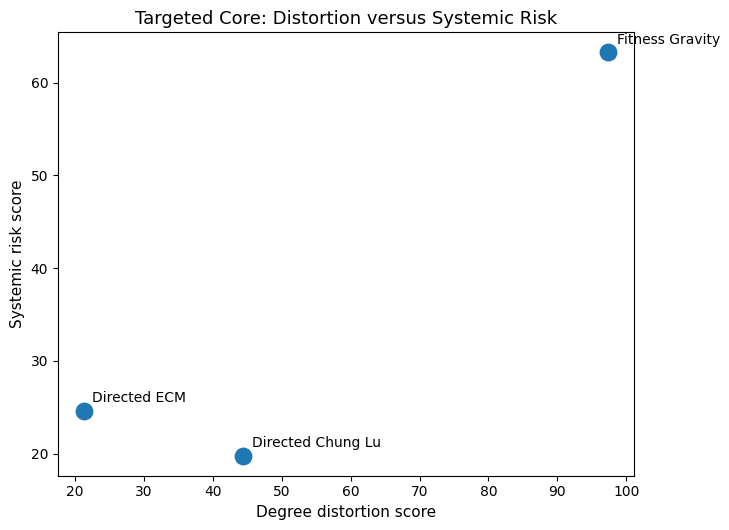

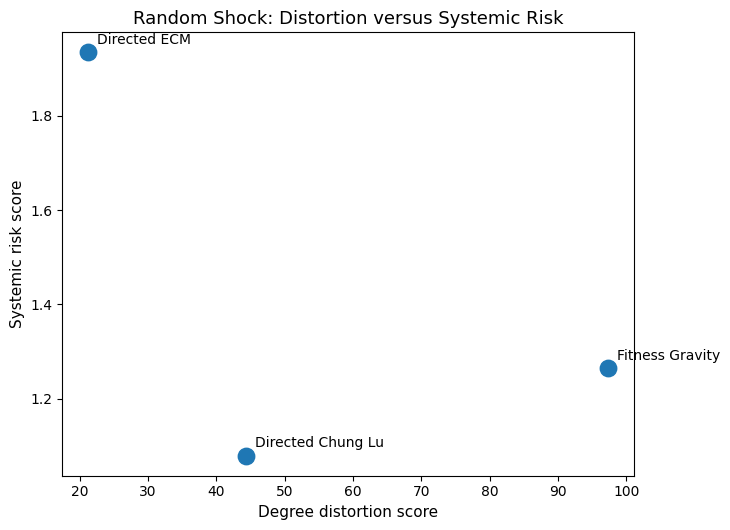

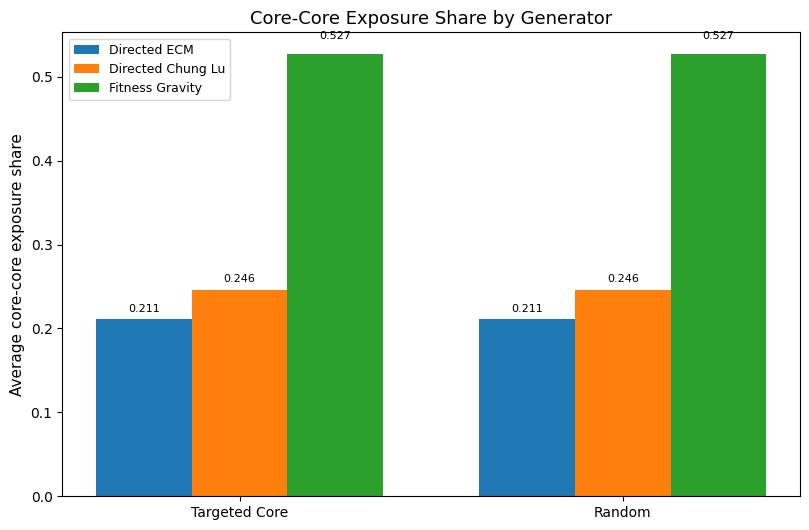

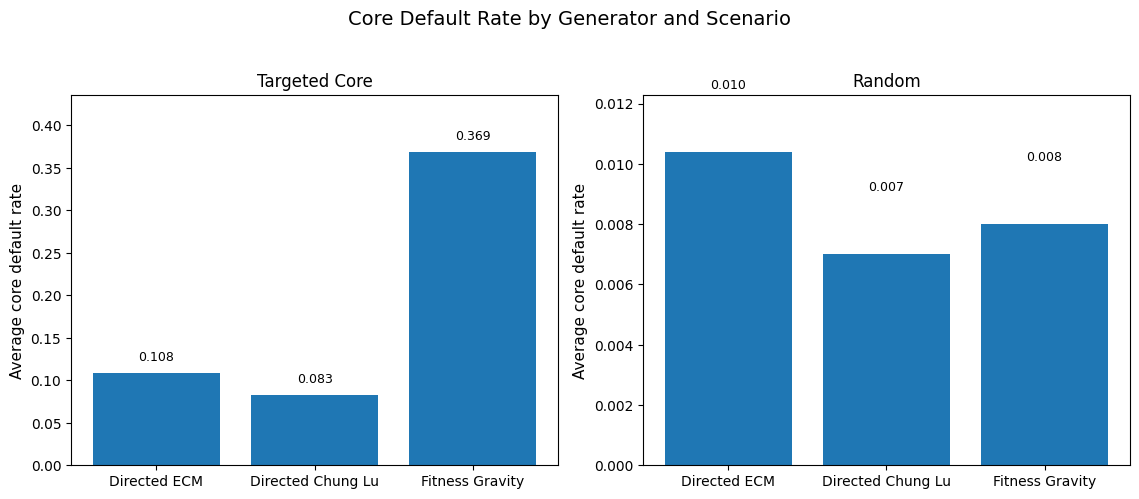

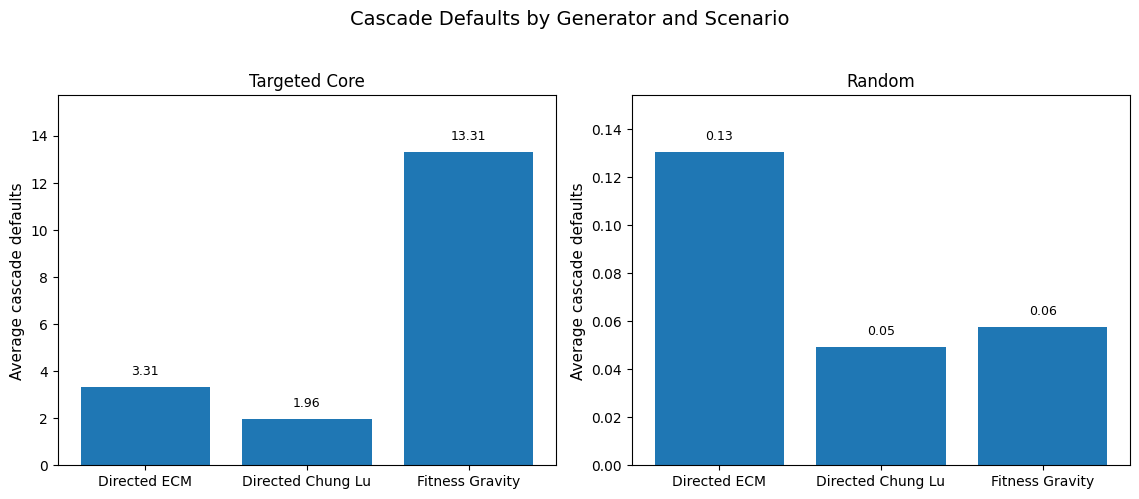

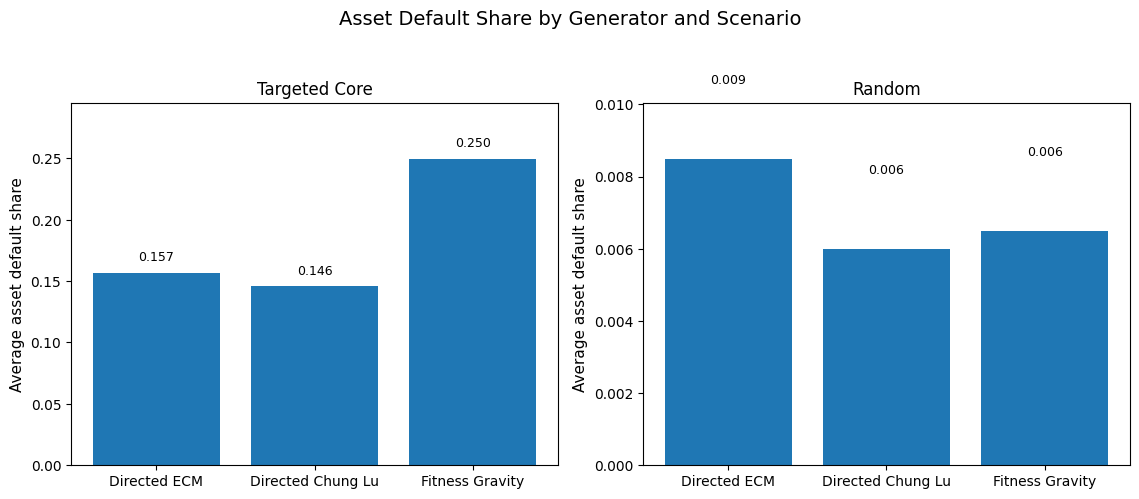

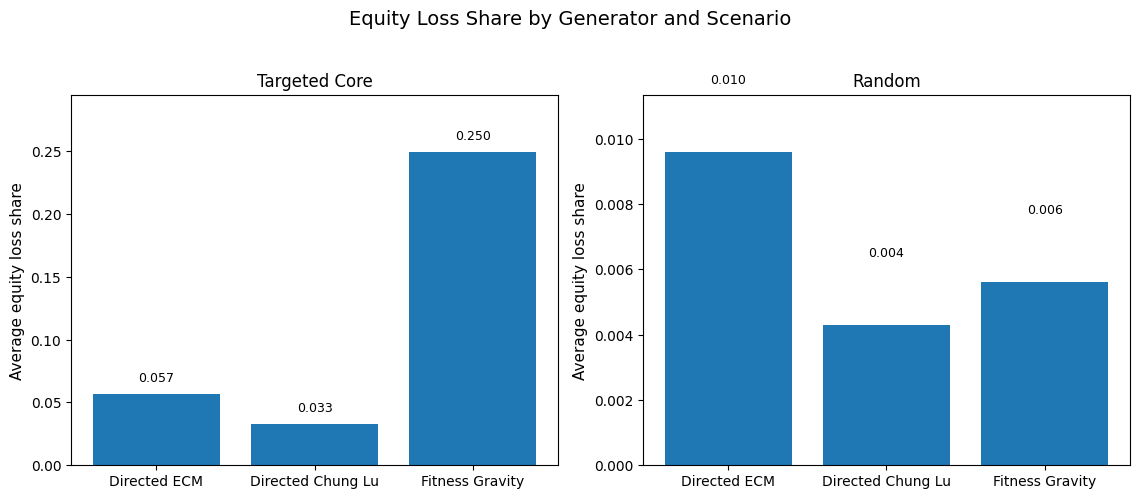

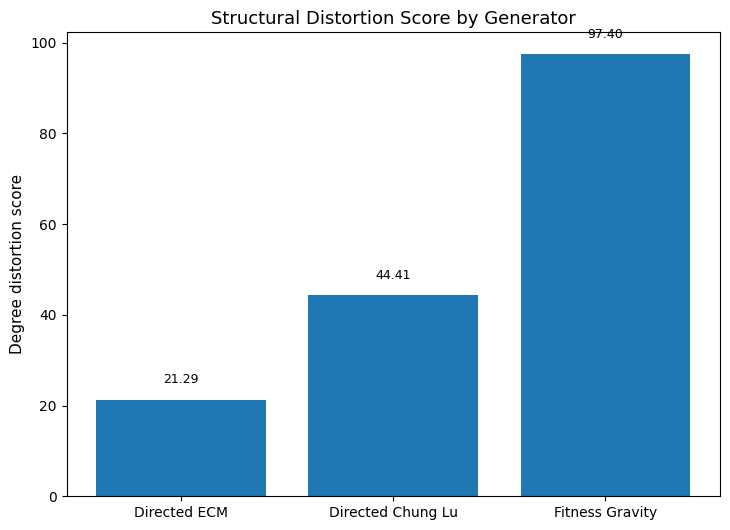

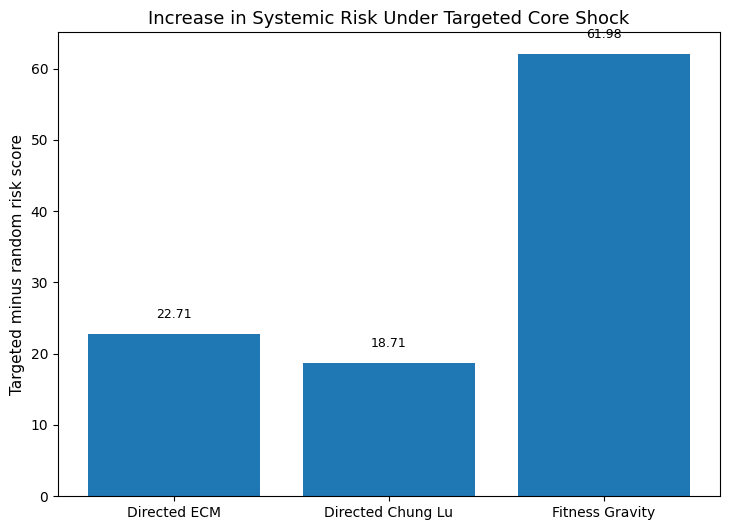


Saved figures to: /content/advanced_banking_output_gpu

Generated files:
- fig_asset_default_share_targeted_vs_random.png
- fig_cascade_defaults_targeted_vs_random.png
- fig_core_core_exposure_share.png
- fig_core_default_rate_targeted_vs_random.png
- fig_equity_loss_share_targeted_vs_random.png
- fig_random_distortion_vs_risk.png
- fig_structural_distortion_scores.png
- fig_targeted_distortion_vs_risk.png
- fig_targeted_vs_random_risk_gap.png


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Load outputs
# =========================================================

out_dir = Path("advanced_banking_output_gpu")
out_dir.mkdir(parents=True, exist_ok=True)

overall_summary = pd.read_csv(out_dir / "paper_overall_summary_by_scenario.csv")
paper_structural = pd.read_csv(out_dir / "paper_structural_table_by_scenario.csv")
paper_contagion = pd.read_csv(out_dir / "paper_contagion_table_by_scenario.csv")
robustness = pd.read_csv(out_dir / "paper_robustness_table_by_scenario.csv")

# Nicer model labels
label_map = {
    "Directed_ECM": "Directed ECM",
    "Directed_ChungLu": "Directed Chung Lu",
    "Fitness_Gravity": "Fitness Gravity",
}

overall_summary["model_label"] = overall_summary["model"].map(label_map).fillna(overall_summary["model"])
paper_structural["model_label"] = paper_structural["model"].map(label_map).fillna(paper_structural["model"])
paper_contagion["model_label"] = paper_contagion["model"].map(label_map).fillna(paper_contagion["model"])
robustness["model_label"] = robustness["model"].map(label_map).fillna(robustness["model"])

MODEL_ORDER = ["Directed ECM", "Directed Chung Lu", "Fitness Gravity"]
SCENARIO_ORDER = ["Targeted_Core", "Random"]
SCENARIO_LABELS = {
    "Targeted_Core": "Targeted Core",
    "Random": "Random",
}

# =========================================================
# Helper plotting functions
# =========================================================

def add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=9):
    heights = [bar.get_height() for bar in bars]
    ymax = max(heights) if len(heights) > 0 else 0.0
    offset = max(ymax * 0.03, 0.002)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + offset,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

def save_scatter_by_scenario(df, scenario, xcol, ycol, title, xlabel, ylabel, filename):
    tmp = df[df["shock_scenario"] == scenario].copy()

    plt.figure(figsize=(7.4, 5.4))
    plt.scatter(tmp[xcol], tmp[ycol], s=140)

    for _, row in tmp.iterrows():
        plt.annotate(
            row["model_label"],
            (row[xcol], row[ycol]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10
        )

    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

def save_bar(df, xcol, ycol, title, ylabel, filename, order=None, fmt="{:.2f}"):
    tmp = df.copy()
    if order is not None:
        tmp[xcol] = pd.Categorical(tmp[xcol], categories=order, ordered=True)
        tmp = tmp.sort_values(xcol)

    plt.figure(figsize=(7.4, 5.4))
    ax = plt.gca()
    bars = ax.bar(tmp[xcol], tmp[ycol])

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    add_bar_labels(ax, bars, fmt=fmt, fontsize=9)

    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

def save_grouped_bar(df, scenario_col, model_col, value_col, title, ylabel, filename,
                     scenario_order=None, model_order=None, fmt="{:.3f}"):
    """
    Use when scales across scenarios are reasonably comparable.
    """
    tmp = df.copy()

    if scenario_order is None:
        scenario_order = list(tmp[scenario_col].drop_duplicates())
    if model_order is None:
        model_order = list(tmp[model_col].drop_duplicates())

    pivot = (
        tmp.pivot(index=scenario_col, columns=model_col, values=value_col)
           .reindex(index=scenario_order, columns=model_order)
    )

    x = np.arange(len(pivot.index))
    width = 0.25

    plt.figure(figsize=(8.2, 5.4))
    ax = plt.gca()

    for i, col in enumerate(pivot.columns):
        bars = ax.bar(x + (i - 1) * width, pivot[col].values, width=width, label=col)
        add_bar_labels(ax, bars, fmt=fmt, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([SCENARIO_LABELS.get(v, v) for v in pivot.index], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.tick_params(axis="y", labelsize=10)

    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

def save_faceted_bar_by_scenario(df, scenario_col, model_col, value_col, title, ylabel, filename,
                                 scenario_order=None, model_order=None, fmt="{:.3f}"):
    """
    Best when one scenario is much larger than the other.
    Creates one subplot per scenario with its own y-scale.
    """
    tmp = df.copy()

    if scenario_order is None:
        scenario_order = list(tmp[scenario_col].drop_duplicates())
    if model_order is None:
        model_order = list(tmp[model_col].drop_duplicates())

    fig, axes = plt.subplots(1, len(scenario_order), figsize=(11.5, 4.8), sharey=False)

    if len(scenario_order) == 1:
        axes = [axes]

    for ax, scenario in zip(axes, scenario_order):
        sub = tmp[tmp[scenario_col] == scenario].copy()
        sub[model_col] = pd.Categorical(sub[model_col], categories=model_order, ordered=True)
        sub = sub.sort_values(model_col)

        bars = ax.bar(sub[model_col], sub[value_col])
        add_bar_labels(ax, bars, fmt=fmt, fontsize=9)

        ax.set_title(SCENARIO_LABELS.get(scenario, scenario), fontsize=12)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.tick_params(axis="x", labelrotation=0, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)

        ymax = sub[value_col].max()
        if pd.notna(ymax):
            ax.set_ylim(0, ymax * 1.18 + 1e-12)

    fig.suptitle(title, fontsize=14, y=1.03)
    plt.tight_layout()
    plt.savefig(out_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# 1) Distortion vs systemic risk scatter: Targeted Core
# =========================================================

save_scatter_by_scenario(
    df=overall_summary,
    scenario="Targeted_Core",
    xcol="degree_distortion_score",
    ycol="systemic_risk_score",
    title="Targeted Core: Distortion versus Systemic Risk",
    xlabel="Degree distortion score",
    ylabel="Systemic risk score",
    filename="fig_targeted_distortion_vs_risk.png",
)

# =========================================================
# 2) Distortion vs systemic risk scatter: Random
# =========================================================

save_scatter_by_scenario(
    df=overall_summary,
    scenario="Random",
    xcol="degree_distortion_score",
    ycol="systemic_risk_score",
    title="Random Shock: Distortion versus Systemic Risk",
    xlabel="Degree distortion score",
    ylabel="Systemic risk score",
    filename="fig_random_distortion_vs_risk.png",
)

# =========================================================
# 3) Core-core exposure share by model and scenario
# =========================================================

core_exposure_df = (
    overall_summary[["shock_scenario", "model_label", "avg_share_cc_exposure"]]
    .drop_duplicates()
    .copy()
)

save_grouped_bar(
    df=core_exposure_df,
    scenario_col="shock_scenario",
    model_col="model_label",
    value_col="avg_share_cc_exposure",
    title="Core-Core Exposure Share by Generator",
    ylabel="Average core-core exposure share",
    filename="fig_core_core_exposure_share.png",
    scenario_order=SCENARIO_ORDER,
    model_order=MODEL_ORDER,
    fmt="{:.3f}",
)

# =========================================================
# 4) Core default rate by model and scenario
# =========================================================

core_default_df = (
    paper_contagion[["shock_scenario", "model_label", "avg_core_default_rate"]]
    .drop_duplicates()
    .copy()
)

save_faceted_bar_by_scenario(
    df=core_default_df,
    scenario_col="shock_scenario",
    model_col="model_label",
    value_col="avg_core_default_rate",
    title="Core Default Rate by Generator and Scenario",
    ylabel="Average core default rate",
    filename="fig_core_default_rate_targeted_vs_random.png",
    scenario_order=SCENARIO_ORDER,
    model_order=MODEL_ORDER,
    fmt="{:.3f}",
)

# =========================================================
# 5) Cascade defaults by model and scenario
# =========================================================

cascade_df = (
    paper_contagion[["shock_scenario", "model_label", "avg_cascade_defaults"]]
    .drop_duplicates()
    .copy()
)

save_faceted_bar_by_scenario(
    df=cascade_df,
    scenario_col="shock_scenario",
    model_col="model_label",
    value_col="avg_cascade_defaults",
    title="Cascade Defaults by Generator and Scenario",
    ylabel="Average cascade defaults",
    filename="fig_cascade_defaults_targeted_vs_random.png",
    scenario_order=SCENARIO_ORDER,
    model_order=MODEL_ORDER,
    fmt="{:.2f}",
)

# =========================================================
# 6) Asset default share by model and scenario
# =========================================================

asset_default_df = (
    paper_contagion[["shock_scenario", "model_label", "avg_asset_default_share"]]
    .drop_duplicates()
    .copy()
)

save_faceted_bar_by_scenario(
    df=asset_default_df,
    scenario_col="shock_scenario",
    model_col="model_label",
    value_col="avg_asset_default_share",
    title="Asset Default Share by Generator and Scenario",
    ylabel="Average asset default share",
    filename="fig_asset_default_share_targeted_vs_random.png",
    scenario_order=SCENARIO_ORDER,
    model_order=MODEL_ORDER,
    fmt="{:.3f}",
)

# =========================================================
# 7) Equity loss share by model and scenario
# =========================================================

equity_loss_df = (
    paper_contagion[["shock_scenario", "model_label", "avg_equity_loss_share"]]
    .drop_duplicates()
    .copy()
)

save_faceted_bar_by_scenario(
    df=equity_loss_df,
    scenario_col="shock_scenario",
    model_col="model_label",
    value_col="avg_equity_loss_share",
    title="Equity Loss Share by Generator and Scenario",
    ylabel="Average equity loss share",
    filename="fig_equity_loss_share_targeted_vs_random.png",
    scenario_order=SCENARIO_ORDER,
    model_order=MODEL_ORDER,
    fmt="{:.3f}",
)

# =========================================================
# 8) Structural distortion scores by model
# =========================================================

distortion_targeted = overall_summary[overall_summary["shock_scenario"] == "Targeted_Core"].copy()
distortion_targeted = distortion_targeted.sort_values("degree_distortion_score")

save_bar(
    df=distortion_targeted,
    xcol="model_label",
    ycol="degree_distortion_score",
    title="Structural Distortion Score by Generator",
    ylabel="Degree distortion score",
    filename="fig_structural_distortion_scores.png",
    order=MODEL_ORDER,
    fmt="{:.2f}",
)

# =========================================================
# 9) Targeted-vs-random risk gap
# =========================================================

risk_gap = (
    overall_summary.pivot(index="model_label", columns="shock_scenario", values="systemic_risk_score")
    .reset_index()
)
risk_gap["risk_gap_targeted_minus_random"] = risk_gap["Targeted_Core"] - risk_gap["Random"]
risk_gap = risk_gap.sort_values("risk_gap_targeted_minus_random", ascending=False)

save_bar(
    df=risk_gap,
    xcol="model_label",
    ycol="risk_gap_targeted_minus_random",
    title="Increase in Systemic Risk Under Targeted Core Shock",
    ylabel="Targeted minus random risk score",
    filename="fig_targeted_vs_random_risk_gap.png",
    order=MODEL_ORDER,
    fmt="{:.2f}",
)

print("\nSaved figures to:", out_dir.resolve())
print("\nGenerated files:")
for f in sorted(out_dir.glob("fig_*.png")):
    print("-", f.name)

In [ ]:
from pathlib import Path
import shutil
import zipfile

# =========================================================
# Paths
# =========================================================

source_dir = Path("advanced_banking_output_gpu")
bundle_dir = Path("overleaf_bundle")
zip_path = Path("overleaf_bundle.zip")

bundle_dir.mkdir(exist_ok=True)

# Clean old bundle contents
for p in bundle_dir.iterdir():
    if p.is_file():
        p.unlink()
    elif p.is_dir():
        shutil.rmtree(p)

# =========================================================
# Files to include
# =========================================================

wanted_files = [
    # Main paper figures
    "fig_targeted_distortion_vs_risk.png",
    "fig_random_distortion_vs_risk.png",
    "fig_core_core_exposure_share.png",
    "fig_core_default_rate_targeted_vs_random.png",
    "fig_cascade_defaults_targeted_vs_random.png",
    "fig_targeted_vs_random_risk_gap.png",

    # Additional paper figures
    "fig_asset_default_share_targeted_vs_random.png",
    "fig_equity_loss_share_targeted_vs_random.png",
    "fig_structural_distortion_scores.png",

    # Paper-ready CSV outputs
    "paper_overall_summary_by_scenario.csv",
    "paper_structural_table_by_scenario.csv",
    "paper_contagion_table_by_scenario.csv",
    "paper_robustness_table_by_scenario.csv",

    # Useful run summaries if present
    "advanced_distortion_summary.csv",
    "advanced_contagion_summary.csv",
]

# =========================================================
# Copy files into bundle
# =========================================================

copied = []
missing = []

for fname in wanted_files:
    src = source_dir / fname
    dst = bundle_dir / fname

    if src.exists():
        shutil.copy2(src, dst)
        copied.append(fname)
    else:
        missing.append(fname)

# Optional: include main.tex automatically if it exists locally
for tex_name in ["main.tex", "paper.tex"]:
    tex_path = Path(tex_name)
    if tex_path.exists():
        shutil.copy2(tex_path, bundle_dir / "main.tex")
        copied.append("main.tex")
        break

# =========================================================
# Create zip
# =========================================================

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(bundle_dir.iterdir()):
        zf.write(f, arcname=f.name)

# =========================================================
# Report
# =========================================================

print("Copied files:")
for f in copied:
    print(" -", f)

if missing:
    print("\nMissing files:")
    for f in missing:
        print(" -", f)

print("\nCreated zip:", zip_path.resolve())
print("Bundle folder:", bundle_dir.resolve())

# =========================================================
# Download in Colab
# =========================================================

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("\nAutomatic download not available in this environment.")
    print("You can manually download:", zip_path)

Copied files:
 - fig_targeted_distortion_vs_risk.png
 - fig_random_distortion_vs_risk.png
 - fig_core_core_exposure_share.png
 - fig_core_default_rate_targeted_vs_random.png
 - fig_cascade_defaults_targeted_vs_random.png
 - fig_targeted_vs_random_risk_gap.png
 - fig_asset_default_share_targeted_vs_random.png
 - fig_equity_loss_share_targeted_vs_random.png
 - fig_structural_distortion_scores.png
 - paper_overall_summary_by_scenario.csv
 - paper_structural_table_by_scenario.csv
 - paper_contagion_table_by_scenario.csv
 - paper_robustness_table_by_scenario.csv
 - advanced_distortion_summary.csv
 - advanced_contagion_summary.csv

Created zip: /content/overleaf_bundle.zip
Bundle folder: /content/overleaf_bundle


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>